<a href="https://colab.research.google.com/github/abdullahcankibritoglu/carboncast/blob/main/yz50_hafta5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Starter Code***

# ***GÖREV 1***

**1. Geçen haftaki MLP + BatchNorm modelini videodaki gibi küçük adımlara böl (logits, counts, probs, logprobs, ...) ve loss.backward() ile her ara değişkenin gradient'ini al. (Egzersiz 1, videonun ilk yarısı)**

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words =  open("names.txt","r").read().splitlines()

In [3]:
chars = sorted(list(set("".join(words))))
stoi = {s : i + 1 for i,s in enumerate(chars)}
stoi["."] = 0
#items() metodu, bir sözlüğün (dictionary) hem anahtarlarını (keys) hem de değerlerini (values) aynı anda tuple (demet) çiftleri halinde almanızı sağlar
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)

In [4]:
block_size = 3

def build_dataset(words):

  X = []
  Y = []

  for w in words:
    context = [0] * block_size
    for ch in w + ".":
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y


import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
X_train,Y_train = build_dataset(words[:n1])
X_dev,Y_dev = build_dataset(words[n1:n2])
X_test,Y_test = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


**buradaki kodda s --> türevin string halini "dlogprobs" gibi
               dt --> bu bizim elle hesapladığımızı türevi
               t --> bu da pytorch un otomatik hesapladığı türev
               torch.all() bütün değerler birebir aynı mı diye bakıyor
               torch.allclose() bütün değerler yaklaşık olarak aynı mı diye bakıyor ufak farkları önemsemyor**
              

In [5]:
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item() # exact ve tensor döndürür bu sebple .item() var
  app = torch.allclose(dt,t.grad)# approximately ve boolean döndürür
  maxdiff = (dt - t.grad).abs().max().item() # maximum difference
  print(
    f'{s:15s} | '
    f'exact: {str(ex):5s} | '
    f'approximate: {str(app):5s} | '
    f'maxdiff: {maxdiff}'
)

In [6]:
n_emb = 10
n_hidden = 64

g = torch.Generator().manual_seed(42)
C = torch.randn(vocab_size,n_emb) #(27,10)

W1 = torch.randn((n_emb * block_size,n_hidden), generator= g)
b1 = torch.randn((n_hidden,),generator=g)

W2 = torch.randn((n_hidden,vocab_size), generator= g)
b2 = torch.randn((vocab_size,),generator=g)


bngain = torch.randn((1,n_hidden)) * 0.1 + 0.1 # Normalizasyon sonrası verinin ölçeğini ayarlar w
bnbias = torch.randn((1,n_hidden)) * 0.1


parameters = [C, W1, W2, b1, b2, bngain,bnbias]
print(sum(p.nelement()) for p in parameters)
for p in parameters:
  p.requires_grad = True



<generator object <genexpr> at 0x7c1370478660>


In [7]:
batch_size = 32
n = batch_size # Videoda kolaylık sağlasın diye kullanılıyor.
ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
Xb,Yb = X_train[ix],Y_train[ix] # rastgele 32 tane satır seçiliyor

In [8]:
emb = C[Xb]
embcat = emb.view(emb.shape[0],-1) # -1 burada ilk 32 yi tut kalanını sen ototmatik hesapla

#Linear Layer 1

hprebn = embcat @ W1 + b1
bnmeani =  1 / n * hprebn.sum(0, keepdim=True) # aslında bu hprebn.mean(0,keepdim = True) burada Karpathy türev alırken kolaylık olsun diye bu halde bırakıyor.
bndiff = hprebn - bnmeani # Amaç: değerleri merkeze çekmek
bndiff2 = bndiff ** 2
bnvar = 1 / (n - 1) * bndiff2.sum(0, keepdim=True)
bnvar_inv = (bnvar + 1e-5) ** -0.5
bnraw = bndiff * bnvar_inv # değerleri standardize ediyor ortalama = 0, standart sapma = 1
hpreact = bngain * bnraw + bnbias # BatchNorm modeli kısıtlamaz; sadece ona daha stabil bir başlangıç noktası sağlar
h = torch.tanh(hpreact)

logits = h @ W2 + b2
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # bu işlem sonucu değiştirmez sadece exp() alınıdğında sayının aşırı büyümesine karşın önlem alır.
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim = True)
counts_sum_inv = counts_sum ** -1 # Karpathy'nin 1 / count_sum kullanmama nedeni backprob sırasında kesin bir şey elde edememesi
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n),Yb].mean()


for p in parameters:
  p.grad = None

for t in [
    logprobs, probs, counts, counts_sum, counts_sum_inv,
    norm_logits, logit_maxes, logits, h, hpreact, bnraw,
    bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
    embcat, emb
]:
    t.retain_grad()

loss.backward()
loss

tensor(4.3798, grad_fn=<NegBackward0>)

In [9]:
[itos[i.item()] for i in Yb[:10]]

['n', 'i', 'l', 'l', 'l', 'r', 'y', 't', '.', 'm']

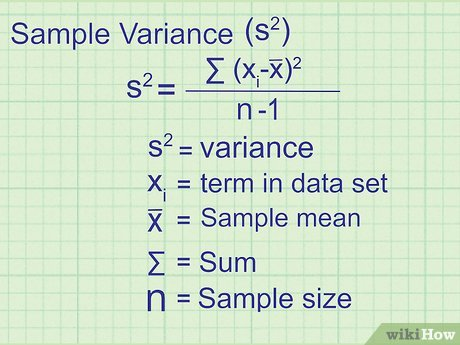


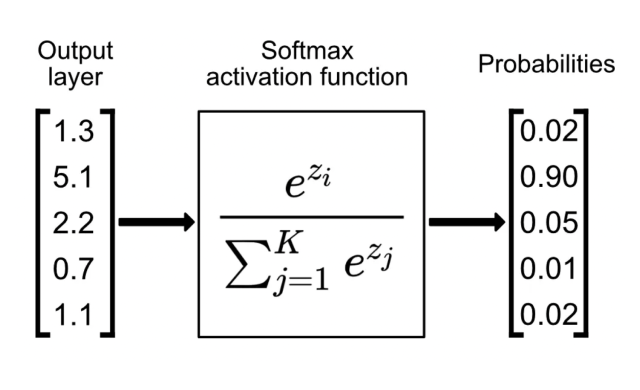




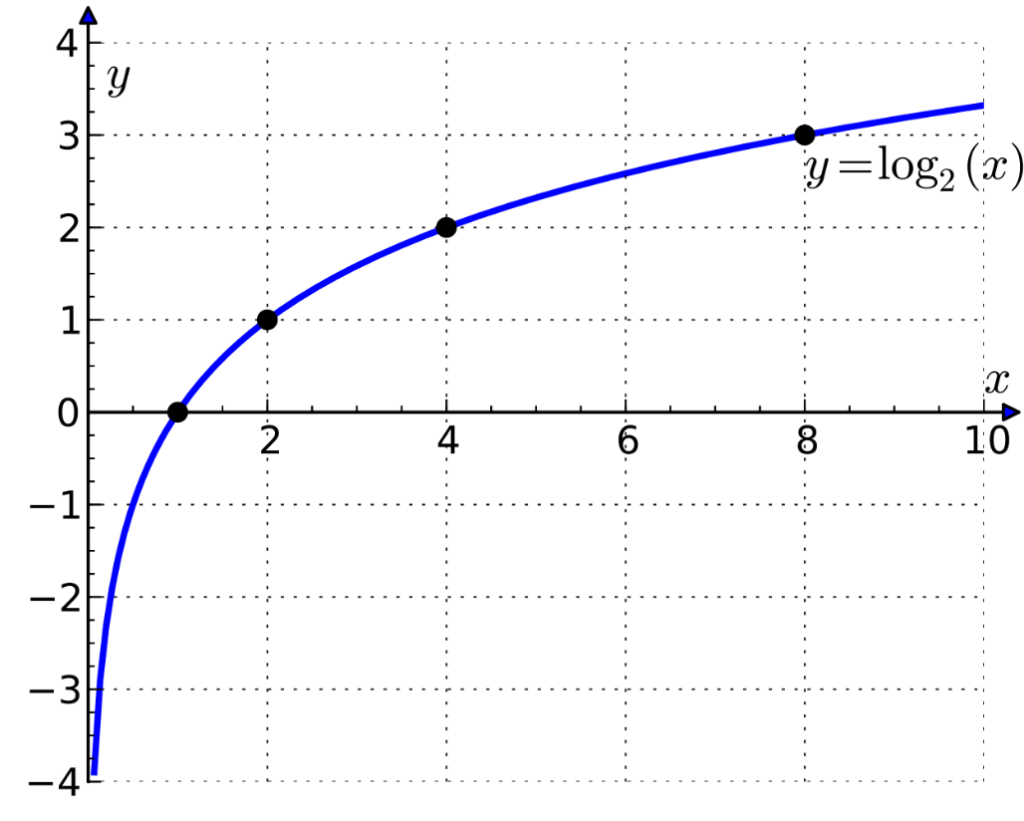

# ***GÖREV 2***

**Aynı gradient'leri elle yaz, cmp fonksiyonuyla tek tek karşılaştır. Hepsi "exact" ya da "approximate" olana kadar devam et. Takıldığın türevi videoda bul, ama önce kendin dene.**

$$
dX = \frac{\partial loss}{\partial X}
$$

$$
dlogprobs[range(n), Yb] = -\frac{1}{n}
$$

$$
dprobs = dlogprobs \cdot \frac{1}{probs}
$$

$$
dcounts\_sum\_inv =
\sum_j counts_j \cdot dprobs_j
$$

$$
dcounts =
counts\_sum\_inv \cdot dprobs
$$

$$
dcounts\_sum =
-counts\_sum^{-2} \cdot dcounts\_sum\_inv
$$

$$
dcounts \mathrel{+}=
\mathbf{1} \cdot dcounts\_sum
$$

$$
dnorm\_logits =
counts \cdot dcounts
$$

$$
dlogits =
dnorm\_logits
$$

$$
dlogit\_maxes =
-\sum_j dnorm\_logits_j
$$

$$
dlogits \mathrel{+}=
\operatorname{one\_hot}
\left(
\operatorname{argmax}_j(logits_j)
\right)
\cdot dlogit\_maxes
$$

$$
dh =
dlogits \cdot W_2^T
$$

$$
dW_2 =
h^T \cdot dlogits
$$

$$
db_2 =
\sum_{\text{batch}} dlogits
$$

$$
dhpreact =
(1-h^2)\cdot dh
$$

$$
dbngain =
\sum_{\text{batch}}
bnraw \cdot dhpreact
$$

$$
dbnbias =
\sum_{\text{batch}}
dhpreact
$$

$$
dbnraw =
bngain \cdot dhpreact
$$

$$
dbndiff =
bnvar\_inv \cdot dbnraw
$$

$$
dbnvar\_inv =
\sum_{\text{batch}}
bndiff \cdot dbnraw
$$

$$
dbnvar =
-0.5
\cdot
(bnvar+\epsilon)^{-1.5}
\cdot
dbnvar\_inv
$$

$$
dbndiff2 =
\frac{1}{n-1}
\cdot
\mathbf{1}
\cdot
dbnvar
$$

$$
dbndiff \mathrel{+}=
2 \cdot bndiff \cdot dbndiff2
$$

$$
dhprebn =
dbndiff
$$

$$
dbnmeani =
-\sum_{\text{batch}} dbndiff
$$

$$
dhprebn \mathrel{+}=
\frac{1}{n}
\cdot
\mathbf{1}
\cdot
dbnmeani
$$

$$
dembcat =
dhprebn \cdot W_1^T
$$

$$
dW_1 =
embcat^T \cdot dhprebn
$$

$$
db_1 =
\sum_{\text{batch}} dhprebn
$$

$$
demb =
\operatorname{reshape}(dembcat,\ emb.shape)
$$

$$
dC_r =
\sum_{\substack{k,j \\ Xb_{k,j}=r}}
demb_{k,j,:}
$$

In [10]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n),Yb] = -1.0 / n
cmp('logprobs',dlogprobs,logprobs)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0


In [11]:
dprobs = dlogprobs * 1 / probs
cmp("probs",dprobs,probs)

probs           | exact: True  | approximate: True  | maxdiff: 0.0


In [12]:
#counts_sum_inv, bir satırdaki bütün olasılıklar için ortak çarpandır. Bu nedenle counts_sum_inve geri dönen gradient, aynı satırdaki bütün karakterlerin katkılarının toplamıdır.
dcounts_sum_inv = (dprobs * counts).sum(1,keepdim = True) #
cmp("counts_sum_inv",dcounts_sum_inv,counts_sum_inv)

counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0


In [13]:
dcounts = dprobs * counts_sum_inv
dcounts_sum = (-counts_sum ** -2) * dcounts_sum_inv
cmp("counts_sum",dcounts_sum, counts_sum)

counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0


In [14]:
dcounts += torch.ones_like(counts) * dcounts_sum
cmp("counts",dcounts,counts)

counts          | exact: True  | approximate: True  | maxdiff: 0.0


In [15]:
dnorm_logits = counts.clone() * dcounts #burada ilk başta copy() kullandım ama tensor da clone kullanılır.
cmp("norm_logits",dnorm_logits,norm_logits)

norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0


In [16]:
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
cmp("logit_maxes", dlogit_maxes, logit_maxes)

logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0


In [17]:
dlogits += (
    F.one_hot(
        logits.max(1).indices,
        num_classes=logits.shape[1]
    )
    * dlogit_maxes
)
cmp("logits", dlogits, logits)

logits          | exact: True  | approximate: True  | maxdiff: 0.0


In [18]:
dh = dlogits @ W2.T
cmp("h",dh,h)

h               | exact: True  | approximate: True  | maxdiff: 0.0


In [19]:
dW2 = h.T @ dlogits
cmp("W2",dW2,W2)

W2              | exact: True  | approximate: True  | maxdiff: 0.0


In [20]:
db2 = dlogits.sum(0) # her batch örneğinin logitlerine eklenir. Bu nedenle db2, batch boyunca dlogits değerlerinin toplamıdır.
cmp("b2", db2, b2)

b2              | exact: True  | approximate: True  | maxdiff: 0.0


In [21]:
dhpreact = (1 - h**2) * dh
cmp("hpreact", dhpreact, hpreact)

hpreact         | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09


In [22]:
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
cmp("bngain", dbngain, bngain)

bngain          | exact: False | approximate: True  | maxdiff: 2.9802322387695312e-08


In [23]:
dbnraw = bngain * dhpreact
cmp("bnraw", dbnraw, bnraw)

bnraw           | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [24]:
dbnbias = dhpreact.sum(0, keepdim=True)
cmp("bnbias", dbnbias, bnbias)

bnbias          | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08


In [25]:
dbndiff = bnvar_inv * dbnraw

dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
cmp("bnvar_inv", dbnvar_inv, bnvar_inv)


bnvar_inv       | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08


In [26]:
dbnvar = (
    -0.5
    * (bnvar + 1e-5)**(-1.5)
    * dbnvar_inv
)
cmp("bnvar", dbnvar, bnvar)

bnvar           | exact: False | approximate: True  | maxdiff: 5.820766091346741e-11


In [27]:
dbndiff2 = (
    (1.0 / (n - 1))
    * torch.ones_like(bndiff2)
    * dbnvar
)
cmp("bndiff2", dbndiff2, bndiff2)


bndiff2         | exact: False | approximate: True  | maxdiff: 1.8189894035458565e-12


In [28]:
dbndiff += 2 * bndiff * dbndiff2
cmp("bndiff", dbndiff, bndiff)

bndiff          | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10


In [29]:
dhprebn = dbndiff.clone()

dbnmeani = (-dbndiff).sum(0, keepdim=True)
cmp("bnmeani", dbnmeani, bnmeani)

bnmeani         | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09


In [30]:
dhprebn += (
    (1.0 / n)
    * torch.ones_like(hprebn)
    * dbnmeani
)
cmp("hprebn", dhprebn, hprebn)

hprebn          | exact: False | approximate: True  | maxdiff: 3.4924596548080444e-10


In [31]:
dembcat = dhprebn @ W1.T
cmp("embcat", dembcat, embcat)

embcat          | exact: False | approximate: True  | maxdiff: 1.3969838619232178e-09


In [32]:
dW1 = embcat.T @ dhprebn
cmp("W1", dW1, W1)

W1              | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09


In [33]:
db1 = dhprebn.sum(0)
cmp("b1", db1, b1)

b1              | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [34]:
demb = dembcat.view(emb.shape)
cmp("emb", demb, emb)

emb             | exact: False | approximate: True  | maxdiff: 1.3969838619232178e-09


In [35]:
dC = torch.zeros_like(C)

for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += demb[k, j]

cmp("C", dC, C)

C               | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
